Top 10 Longest Tracks:
                                          track_name                 artist  \
710                                         Lost Boy                  Jaden   
610                                I'm Getting Ready    Tasha Cobbs Leonard   
64                                           Mirrors      Justin Timberlake   
63   What Goes Around.../...Comes Around (Interlude)      Justin Timberlake   
622                               Achilles Come Down         Gang of Youths   
689                             Never Let Go (Of Me)                 Baltra   
682            House Of Balloons / Glass Table Girls             The Weeknd   
549                                             Stan                 Eminem   
671                                        Galvanize  The Chemical Brothers   
37                                       After Hours             The Weeknd   

     duration_min  
710      9.497883  
610      8.436667  
64       8.069100  
63       7.476217  
622    

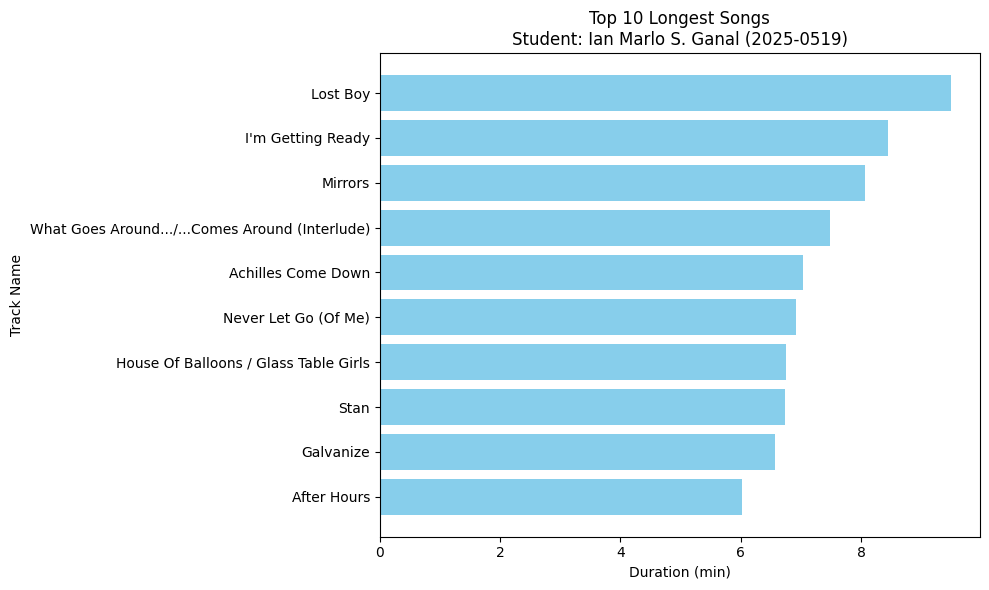

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import seaborn as sns

# --- STUDENT-SPECIFIC PARAMETERS ---
# Update these values with your information
student_name = "Ian Marlo S. Ganal"
student_id = "2025-0519"
color_bar = "skyblue"
color_line = "orange"
cmap_color = "Blues"

# Load the dataset
# Ensure 'spotify_top_1000.csv' is in your working directory
df = pd.read_csv('spotify_top_1000_tracks.csv')

# --- 1. IDENTIFY LONGEST TRACKS ---
# Sort by duration and take top 10
longest_tracks = df.sort_values(by='duration_min', ascending=False).head(10)

# Display table
print("Top 10 Longest Tracks:")
print(longest_tracks[['track_name', 'artist', 'duration_min']])

# Plotting horizontal bar chart
plt.figure(figsize=(10, 6))
plt.barh(longest_tracks['track_name'], longest_tracks['duration_min'], color=color_bar)
plt.xlabel('Duration (min)')
plt.ylabel('Track Name')
plt.title(f'Top 10 Longest Songs\nStudent: {student_name} ({student_id})')
plt.gca().invert_yaxis()  # Put longest at the top
plt.tight_layout()
plt.show()

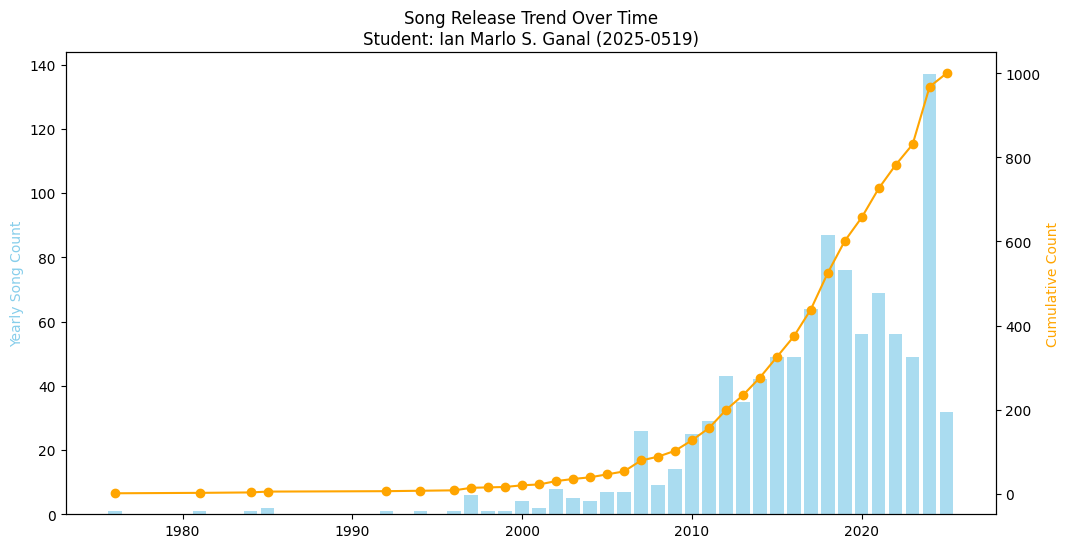

In [8]:
# --- 2. SONG RELEASE TREND ---
# Group by year and count
df['year'] = df['release_date'].str[:4].astype(int)

yearly_counts = df.groupby('year').size().reset_index(name='song_count')
yearly_counts['cumulative_count'] = yearly_counts['song_count'].cumsum()

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.bar(yearly_counts['year'], yearly_counts['song_count'], color=color_bar, alpha=0.7)
ax1.set_ylabel('Yearly Song Count', color=color_bar)

ax2 = ax1.twinx()
ax2.plot(yearly_counts['year'], yearly_counts['cumulative_count'], color=color_line, marker='o')
ax2.set_ylabel('Cumulative Count', color=color_line)

plt.title(f'Song Release Trend Over Time\nStudent: {student_name} ({student_id})')
plt.show()

In [6]:
print(df.columns)

Index(['track_name', 'artist', 'album', 'release_date', 'popularity',
       'spotify_url', 'id', 'duration_min'],
      dtype='str')


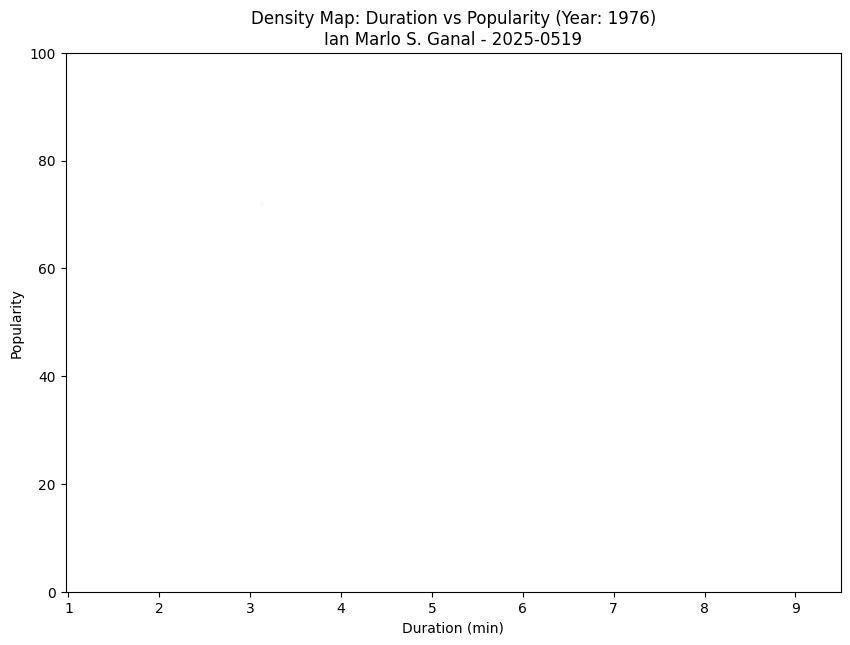

In [16]:
from IPython.display import HTML # Added for notebook display

df['year'] = df['release_date'].str[:4].astype(int)

fig, ax = plt.subplots(figsize=(10, 7))
years = sorted(df['year'].unique())

def update(year):
    ax.clear()
    data_year = df[df['year'] <= year]
    
    # We add a check: only plot if there is actually data for that year
    if not data_year.empty:
        hb = ax.hexbin(data_year['duration_min'], data_year['popularity'], 
                       gridsize=15, cmap=cmap_color, mincnt=1, rasterized=True)
    
    ax.set_title(f'Density Map: Duration vs Popularity (Year: {year})\n{student_name} - {student_id}')
    ax.set_xlabel('Duration (min)')
    ax.set_ylabel('Popularity')
    ax.set_xlim(df['duration_min'].min(), df['duration_min'].max()) # Keep axes steady
    ax.set_ylim(0, 100)
    return []

ani = animation.FuncAnimation(fig, update, frames=years, interval=200, repeat=False)

# This is the most important part for viewing in a browser/notebook:
HTML(ani.to_jshtml())